In [10]:
import os
import xml.etree.ElementTree as ET
import numpy as np
import tensorflow as tf
from tensorflow.keras import models
from tensorflow.keras.layers import Flatten,Dense,Conv2D, MaxPooling2D, Conv2DTranspose, Dropout, Input,UpSampling2D,BatchNormalization,Activation
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics import classification_report, jaccard_score
from sklearn.metrics import average_precision_score, accuracy_score
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import average_precision_score, accuracy_score,precision_recall_fscore_support
import matplotlib.pyplot as plt

DATASET_PATH = "/content/data/VOCdevkit/VOC2008"
IMAGE_DIR = os.path.join(DATASET_PATH, "JPEGImages")
ANN_DIR = os.path.join(DATASET_PATH, "Annotations")
SPLIT_FILE = os.path.join(DATASET_PATH, "ImageSets/Main/train.txt")
IMG_SIZE = (128, 128)

VOC_CLASSES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]
class_to_idx = {cls: i for i, cls in enumerate(VOC_CLASSES)}
# print(len(class_to_idx))

In [11]:
import traceback

images = []
all_boxes = []

with open(SPLIT_FILE, 'r') as f:
    img_ids = f.read().strip().split()

for img_id in img_ids:
    img_path = os.path.join(IMAGE_DIR, img_id + ".jpg")
    ann_path = os.path.join(ANN_DIR, img_id + ".xml")

    try:
        image = Image.open(img_path).convert("RGB")
        orig_w, orig_h = image.size
        image = image.resize(IMG_SIZE)
        image_np = np.array(image) / 255.0
    except Exception as e:
        print(f"[Image Error] {img_path}: {e}")
        traceback.print_exc()
        continue

    try:
        tree = ET.parse(ann_path)
        root = tree.getroot()
        boxes = []
        for obj in root.findall("object"):
            cls = obj.find("name").text.lower().strip()
            if cls not in class_to_idx:
                print(f"[Class Not Found] {cls} in {ann_path}")
                continue
            class_id = class_to_idx[cls]
            bbox = obj.find("bndbox")
            x_min = int(float(bbox.find("xmin").text))
            y_min = int(float(bbox.find("ymin").text))
            x_max = int(float(bbox.find("xmax").text))
            y_max = int(float(bbox.find("ymax").text))

            x_min = int(x_min * IMG_SIZE[0] / orig_w)
            x_max = int(x_max * IMG_SIZE[0] / orig_w)
            y_min = int(y_min * IMG_SIZE[1] / orig_h)
            y_max = int(y_max * IMG_SIZE[1] / orig_h)

            boxes.append([x_min, y_min, x_max, y_max, class_id])

        if boxes:
            images.append(image_np)
            all_boxes.append(np.array(boxes))
        else:
            print(f"[No Boxes] {ann_path}")

    except Exception as e:
        print(f"[Annotation Error] {ann_path}: {e}")
        traceback.print_exc()
        continue
print(f"Total images listed: {len(img_ids)}")
print(f"Images successfully loaded: {len(images)}")

X = np.array(images)
y_boxes = []
y_classes = []

for box_list in all_boxes:
    box = box_list[0]
    x_min, y_min, x_max, y_max, class_id = box
    y_boxes.append([x_min / IMG_SIZE[0], y_min / IMG_SIZE[1],
                    x_max / IMG_SIZE[0], y_max / IMG_SIZE[1]])
    y_classes.append(class_id)

y_boxes = np.array(y_boxes, dtype=np.float32)
y_classes = tf.keras.utils.to_categorical(y_classes, num_classes=len(VOC_CLASSES))

# print(y_boxes.shape)
X_train2, X_val2, box_train, box_val, cls_train, cls_val = train_test_split(X, y_boxes, y_classes, test_size=0.2, random_state=42)
print(X_train2.shape)
print(X_train2.shape)
print(X_val2.shape)


Total images listed: 2111
Images successfully loaded: 2111
(1688, 128, 128, 3)
(1688, 128, 128, 3)
(423, 128, 128, 3)


In [12]:

# X_train2, X_val2, box_train, box_val, cls_train, cls_val = train_test_split(X, y_boxes, y_classes, test_size=0.2, random_state=42)
import os
import xml.etree.ElementTree as ET
import numpy as np
import tensorflow as tf
from tensorflow.keras import models
from tensorflow.keras.layers import Flatten,Dense,Conv2D, MaxPooling2D, Conv2DTranspose, Dropout, Input,UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array


input_img = Input(shape=(128, 128, 3))
x =Conv2D(32, 3, activation='relu')(input_img)
x =MaxPooling2D()(x)
x =Conv2D(64, 3, activation='relu')(x)
x =MaxPooling2D()(x)
x =Conv2D(128, 3, activation='relu')(x)
x =Flatten()(x)
x =Dense(256, activation='relu')(x)
# O1
bbox_output =Dense(4, activation='sigmoid', name='bbox')(x)
# O2
class_output =Dense(len(VOC_CLASSES), activation='softmax', name='class')(x)

model2 = models.Model(inputs=input_img, outputs=[bbox_output, class_output])
model2.compile(
    optimizer='adam',
    loss={'bbox': 'mse', 'class': 'categorical_crossentropy'},
    metrics={'bbox': 'mse', 'class': 'accuracy'}
)

model2.summary()
model2.fit(
    X_train2, {'bbox': box_train, 'class': cls_train},
    validation_data=(X_val2, {'bbox': box_val, 'class': cls_val}),
    epochs=10,
    batch_size=64
)



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 126, 126, 32)   │            896 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 63, 63, 32)     │              0 │ conv2d[0][0]           │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 61, 61, 64)     │         18,496 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 30, 30, 64)     │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 28, 28, 128)    │         73,856 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)         │ (None, 100352)         │              0 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 256)            │     25,690,368 │ flatten[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bbox (Dense)              │ (None, 4)              │          1,028 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ class (Dense)             │ (None, 20)             │          5,140 │ dense[0][0]            │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 25,789,784 (98.38 MB)

 Trainable params: 25,789,784 (98.38 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 239ms/step - bbox_loss: 0.0758 - bbox_mse: 0.0758 - class_accuracy: 0.1658 - class_loss: 3.8689 - loss: 3.9454 - val_bbox_loss: 0.0520 - val_bbox_mse: 0.0524 - val_class_accuracy: 0.2482 - val_class_loss: 2.5407 - val_loss: 2.6124
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - bbox_loss: 0.0471 - bbox_mse: 0.0471 - class_accuracy: 0.2524 - class_loss: 2.5989 - loss: 2.6465 - val_bbox_loss: 0.0508 - val_bbox_mse: 0.0511 - val_class_accuracy: 0.2671 - val_class_loss: 2.4646 - val_loss: 2.5284
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - bbox_loss: 0.0487 - bbox_mse: 0.0487 - class_accuracy: 0.2819 - class_loss: 2.3972 - loss: 2.4459 - val_bbox_loss: 0.0516 - val_bbox_mse: 0.0522 - val_class_accuracy: 0.2719 - val_class_loss: 2.4553 - val_loss: 2.5141
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - bbox_loss: 0.0484 - bbox_mse: 0.0484 - class_accuracy: 0.3098 - class_loss: 2.2629 - loss: 2.3110 - val_bbox_loss: 0.0527 - val_bbo

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

pred_boxes, pred_classes = model2.predict(X_val2)
pred_class_labels = np.argmax(pred_classes, axis=1)
true_class_labels = np.argmax(cls_val, axis=1)




def denormalize_bbox(bbox, img_size=(224, 224)):
    x_min = int(bbox[0] * img_size[0])
    y_min = int(bbox[1] * img_size[1])
    x_max = int(bbox[2] * img_size[0])
    y_max = int(bbox[3] * img_size[1])
    return [x_min, y_min, x_max, y_max]
    # Compute IoU
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])


    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    return intersection / union if union != 0 else 0


ap_per_class = []
for i in range(20):  # 20 classes
    true_class = (true_class_labels == i).astype(int)  # True class
    pred_prob = pred_classes[:, i]  # Predicted class probabilities for class i

    ap = average_precision_score(true_class, pred_prob)
    print(f"Class {VOC_CLASSES[i]} AP: {ap:.4f}")
    ap_per_class.append(ap)

mean_ap = np.mean(ap_per_class)
print(f"Mean Ap: {mean_ap:.4f}")




ious = []
for i in range(len(X_val2)):
    true_box = denormalize_bbox(box_val[i])
    pred_box = denormalize_bbox(pred_boxes[i])

    iou = compute_iou(true_box, pred_box)
    ious.append(iou)

    true_label = np.argmax(cls_val[i])
    pred_label = np.argmax(pred_classes[i])
    # if true_label == pred_label:
    #     correct_class += 1

mean_iou = np.mean(ious)
print(f"Mean IoU (bbox): {mean_iou:.4f}")


accuracy = accuracy_score(true_class_labels, pred_class_labels)
precision, recall, f1_score, _ = precision_recall_fscore_support(true_class_labels, pred_class_labels, average='macro')
print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")



14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Class aeroplane AP: 0.3540
Class bicycle AP: 0.0532
Class bird AP: 0.1166
Class boat AP: 0.2221
Class bottle AP: 0.0243
Class bus AP: 0.1218
Class car AP: 0.1351
Class cat AP: 0.1180
Class chair AP: 0.0438
Class cow AP: 0.0117
Class diningtable AP: 0.0395
Class dog AP: 0.1064
Class horse AP: 0.0770
Class motorbike AP: 0.0531
Class person AP: 0.3331
Class pottedplant AP: 0.0325
Class sheep AP: 0.0330
Class sofa AP: 0.0541
Class train AP: 0.0537
Class tvmonitor AP: 0.0522
Mean Ap: 0.1018
Mean IoU (bbox): 0.2847

Accuracy: 0.1986
Precision: 0.0948
Recall: 0.0978
F1-Score: 0.0922


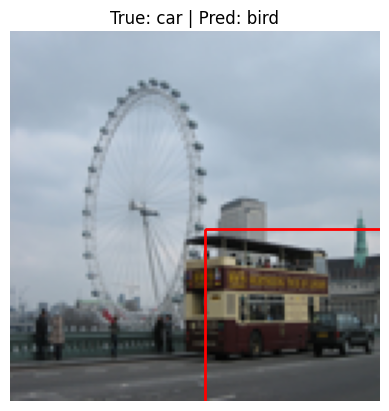

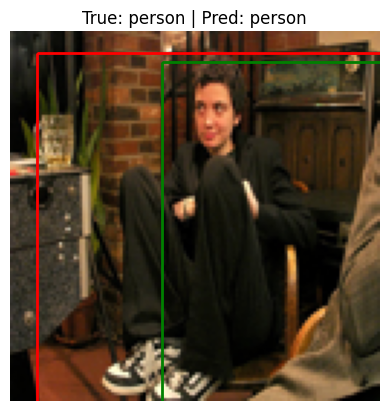

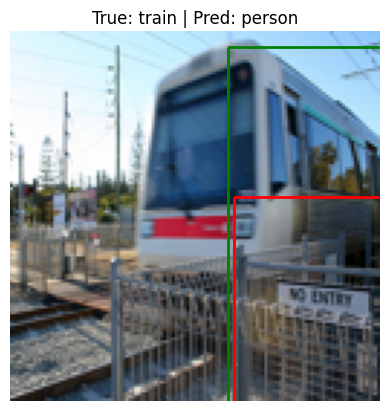

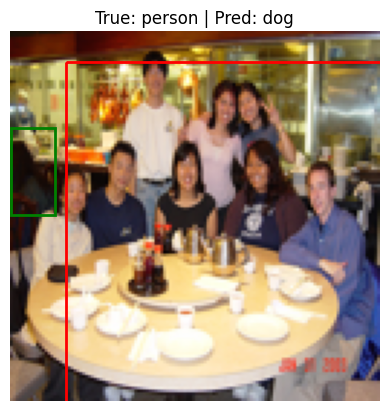

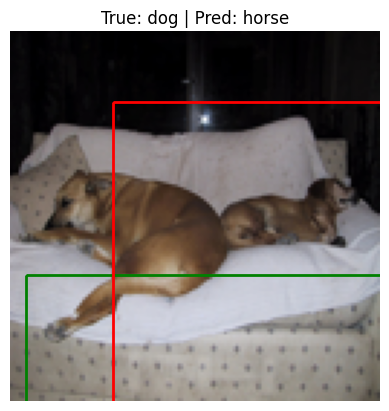

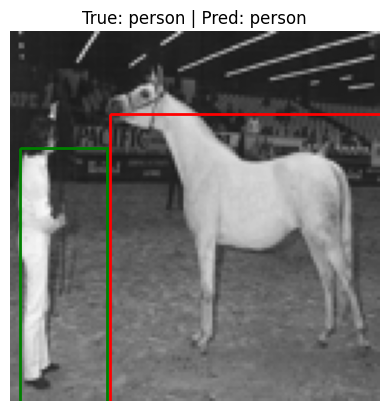

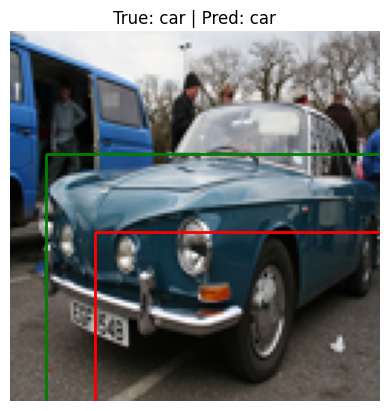

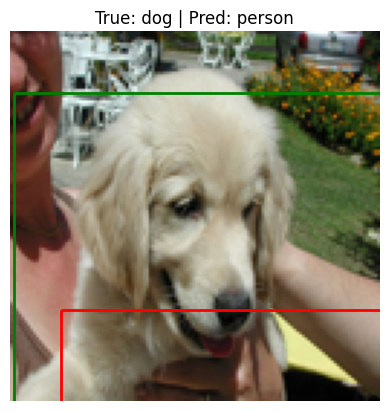

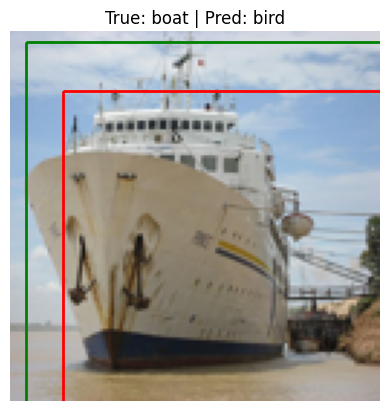

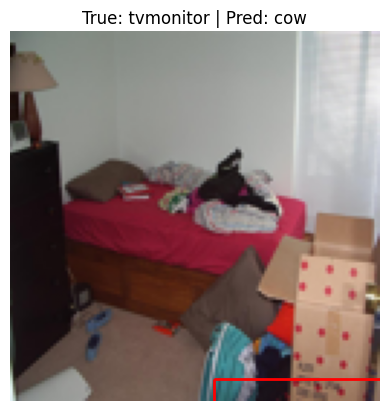

In [39]:
import random


def display(idx):
      img = X_val2[idx]
      true_box = denormalize_bbox(box_val[idx])
      pred_box = denormalize_bbox(pred_boxes[idx])
      true_label = np.argmax(cls_val[idx])
      pred_label = np.argmax(pred_classes[idx])

      plt.imshow(img)
      plt.title(f"True: {VOC_CLASSES[true_label]} | Pred: {VOC_CLASSES[pred_label]}")

      # green box
      plt.gca().add_patch(plt.Rectangle((true_box[0], true_box[1]),
                                        true_box[2]-true_box[0],
                                        true_box[3]-true_box[1],
                                        edgecolor='green', fill=False, lw=2))

      # red box
      plt.gca().add_patch(plt.Rectangle((pred_box[0], pred_box[1]),
                                        pred_box[2]-pred_box[0],
                                        pred_box[3]-pred_box[1],
                                        edgecolor='red', fill=False, lw=2))
      plt.axis('off')
      plt.show()

for i in range(10):
  display(random.randint(0, len(X_val2)))